In [74]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [75]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import datetime
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, Callback
import tensorflow.keras.backend as K

## Dane

In [2]:
import tensorflow as tf

# Ładowanie danych CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalizacja wartości pikseli
x_train, x_test = x_train / 255.0, x_test / 255.0

# Przetwarzanie etykiet na kategorie
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Tworzenie obiektów tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

## Tworzenie modelu

In [3]:
# from tensorflow.keras import layers, models

# model = models.Sequential([
#     layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),
    
#     layers.Conv2D(128, (3, 3), activation='relu'),
#     layers.MaxPooling2D((2, 2)),
#     layers.Dropout(0.25),
    
#     layers.Conv2D(128, (3, 3), activation='relu'),
#     layers.Flatten(),
#     layers.Dropout(0.5),
#     layers.Dense(128, activation='relu'),
#     layers.Dropout(0.5),
#     layers.Dense(10, activation='softmax')
# ])

# model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# # Podsumowanie modelu
# model.summary()

## Trening

In [4]:
# from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
# import os
# import datetime

# # Callbacks
# callbacks = [
#     EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
#     TensorBoard(log_dir='logs/{}'.format(datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
# ]

# # # Dodajemy SimpleLRScheduler do callbacków
# # start_lr = 1e-5
# # end_lr = 1e-1
# # epochs = 100
# # steps_per_epoch = len(train_dataset)
# # num_iterations = steps_per_epoch * epochs  # Łączna liczba iteracji (kroków)
# # lr_scheduler = SimpleLRScheduler(start_lr, end_lr, num_iterations)
# # callbacks.append(lr_scheduler)

# # Trenowanie modelu z nowym callbackiem
# history = model.fit(train_dataset,
#                     epochs=15,
#                     validation_data=test_dataset,
#                     callbacks=callbacks)

In [5]:
# model.save('model_1')

In [6]:
# from tensorflow.keras.models import load_model
# # Wczytaj cały model
# model_base = load_model('model_1')

In [7]:
# model_base.evaluate(test_dataset)

In [8]:
# model.evaluate(test_dataset)

## Model 2

In [9]:
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

# Rozszerzamy architekturę modelu
model_2 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Podsumowanie modelu_2
model_2.summary()

# Przygotowanie callbacków dla modelu_2
callbacks_2 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    TensorBoard(log_dir='logs/model_2/{}'.format(datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
]

# Trenowanie modelu_2
history_model_2 = model_2.fit(train_dataset,
                              epochs=30,  # Zwiększamy liczbę epok
                              validation_data=test_dataset,
                              callbacks=callbacks_2)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 16, 16, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 128)       147584    
                                                        

In [10]:
model_2.evaluate(test_dataset)

313/313 [==============================] - 2s 5ms/step - loss: 0.5800 - accuracy: 0.8148


[0.5800072550773621, 0.8148000240325928]

In [11]:
from tensorflow.keras.models import load_model
model_v2 = load_model('model_2')

In [12]:
model_v2.evaluate(test_dataset)

313/313 [==============================] - 2s 5ms/step - loss: 0.5509 - accuracy: 0.8185


[0.5509307384490967, 0.8184999823570251]

## Wykresy

In [13]:
def plot_history(history):
    plt.figure(figsize=(14, 5))
    
    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    
    plt.show()

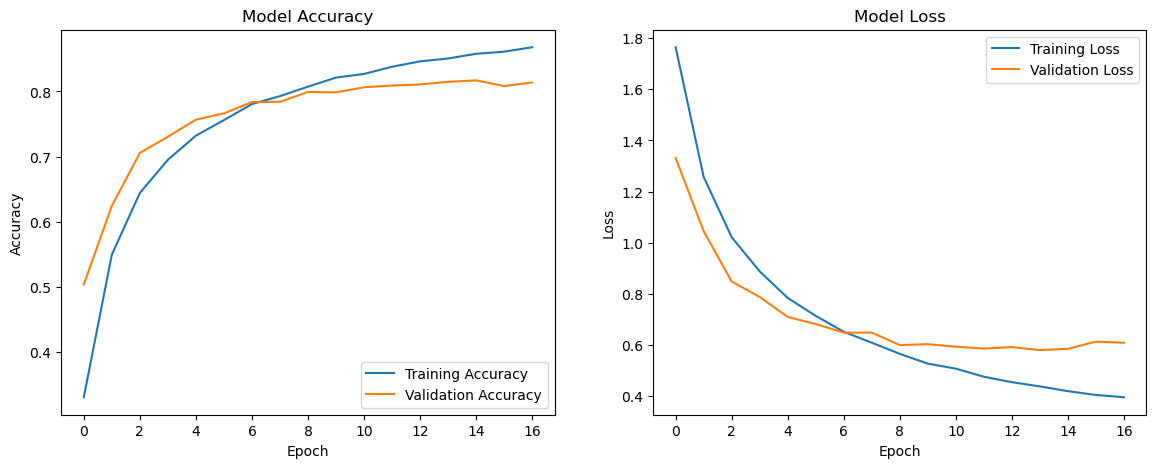

In [14]:
plot_history(history_model_2)

In [80]:
# %reload_ext tensorboard

In [81]:
# %tensorboard --logdir ./logs

## Model 3

In [17]:
from tensorflow.keras import layers, models, callbacks
import tensorflow as tf

model_improved = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),  # Zwiększenie liczby neuronów
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_improved.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

model_improved.summary()

# Przygotowanie callbacków dla ulepszonego modelu
callbacks_improved = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    TensorBoard(log_dir='logs/model_improved/{}'.format(datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)  # Dodatkowy callback do regulacji LR
]

# Trenowanie ulepszonego modelu
history_model_improved = model_improved.fit(train_dataset,
                                            epochs=30,
                                            validation_data=test_dataset,
                                            callbacks=callbacks_improved)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 64)        1792      
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 64)       256       
 ormalization)                                                   
                                                                 
 conv2d_7 (Conv2D)           (None, 32, 32, 64)        36928     
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 64)       256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 16, 16, 64)       0         
 2D)                                                             
                                                      

In [18]:
model_improved.save("model_3")

INFO:tensorflow:Assets written to: model_3\assets


INFO:tensorflow:Assets written to: model_3\assets


In [19]:
model_improved.evaluate(test_dataset)

313/313 [==============================] - 2s 6ms/step - loss: 0.4051 - accuracy: 0.8697


[0.4050658345222473, 0.869700014591217]

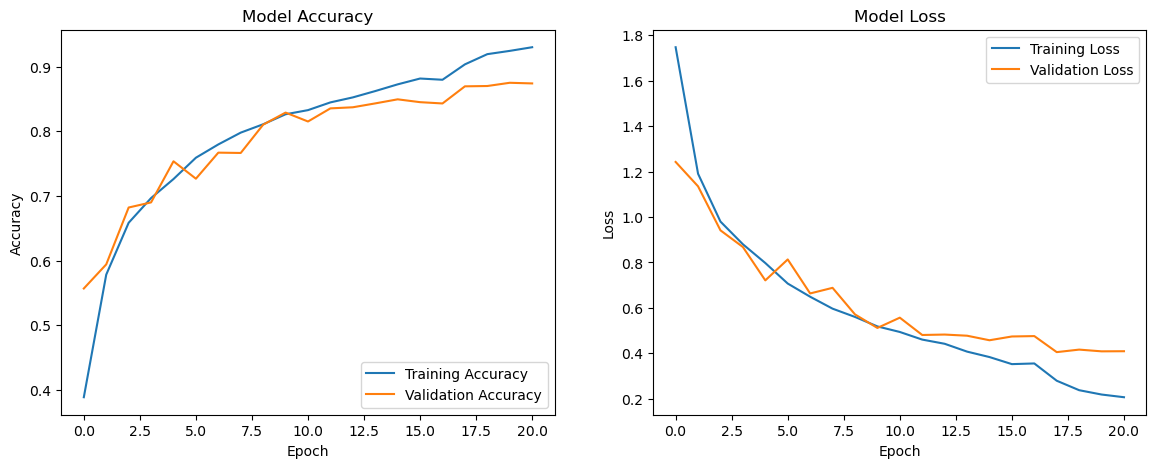

In [20]:
plot_history(history_model_improved)

1/1 [==============================] - 0s 18ms/step


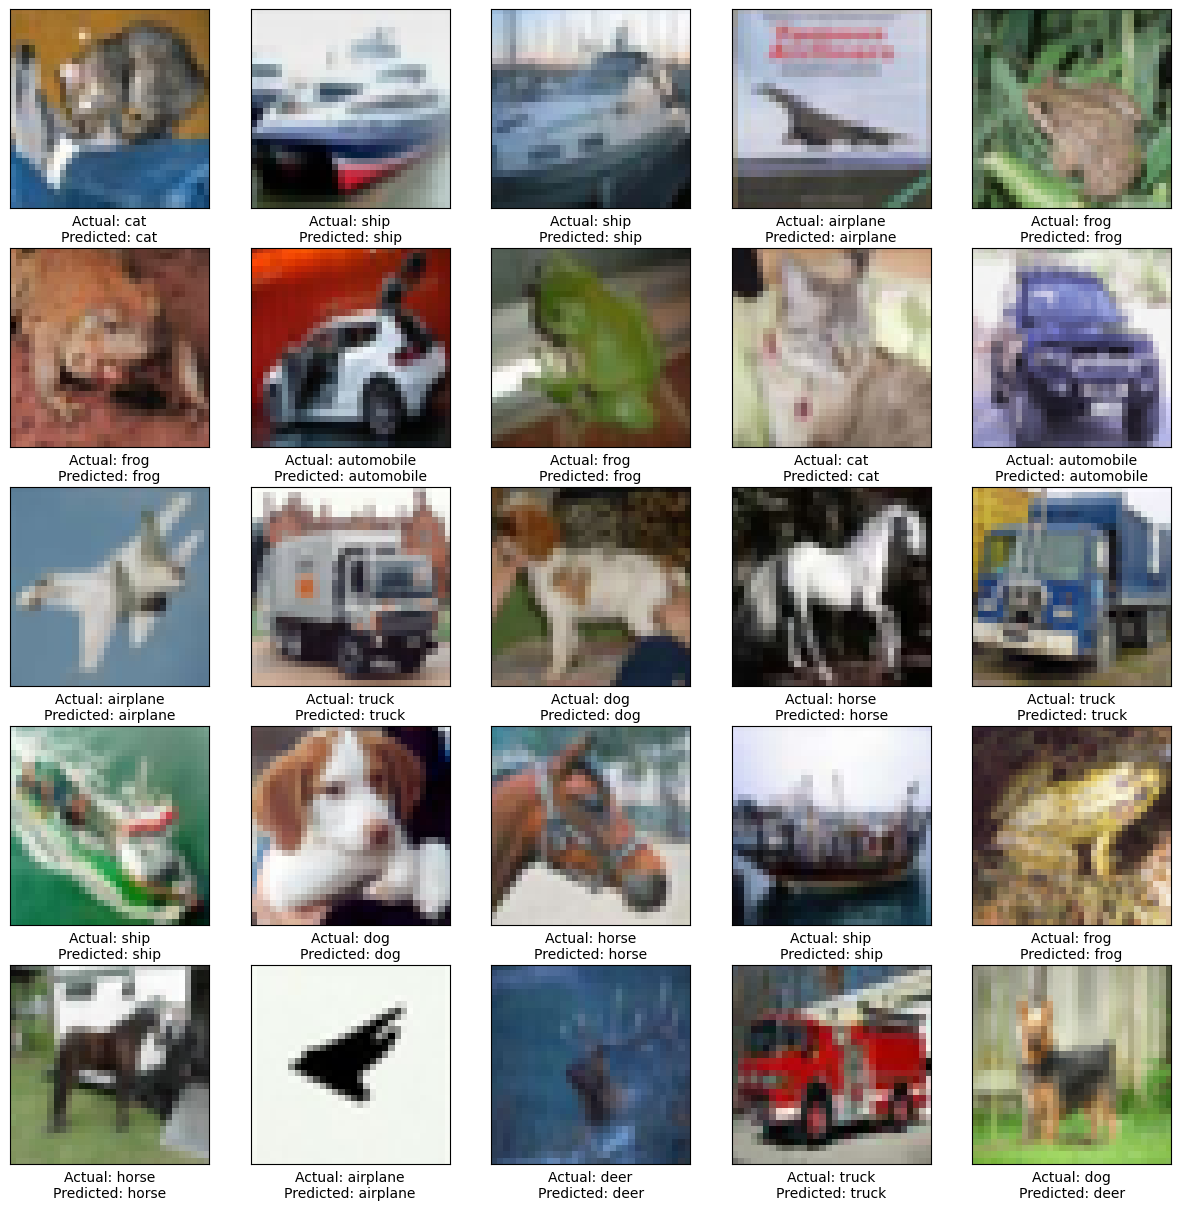

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from helper_functions import display_test_predictions

# Definiujemy nazwy klas dla zbioru CIFAR-10
class_names_cifar10 = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Wygenerowanie przykładowych predykcji
display_test_predictions(model_improved, test_dataset, class_names_cifar10)

In [31]:
import numpy as np

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Przewidywanie klas na zestawie testowym
y_pred = np.argmax(model_improved.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 [==============================] - 2s 5ms/step


In [32]:
# Obliczanie dokładności dla każdej klasy
class_accuracies = []
for class_index in range(len(class_names)):
    correct_predictions = np.sum((y_pred == y_true) & (y_true == class_index))
    total_samples = np.sum(y_true == class_index)
    accuracy = correct_predictions / total_samples if total_samples > 0 else 0
    class_accuracies.append((class_names[class_index], accuracy))

# Sortowanie klas na podstawie skuteczności
sorted_class_accuracies = sorted(class_accuracies, key=lambda x: x[1], reverse=True)

# Wybór top 5 najlepiej przewidywanych klas
top_5_best_classes = sorted_class_accuracies[:5]

# Wybór top 5 najgorzej przewidywanych klas
top_5_worst_classes = sorted_class_accuracies[-5:]

# Wyświetlenie top 5 najlepiej przewidywanych klas
print("Top 5 najlepiej przewidywanych klas:")
for class_name, accuracy in top_5_best_classes:
    print("{}: {:.2f}%".format(class_name, accuracy * 100))

# Wyświetlenie top 5 najgorzej przewidywanych klas
print("\nTop 5 najgorzej przewidywanych klas:")
for class_name, accuracy in top_5_worst_classes:
    print("{}: {:.2f}%".format(class_name, accuracy * 100))

Top 5 najlepiej przewidywanych klas:
automobile: 93.50%
frog: 92.70%
ship: 92.50%
truck: 92.20%
airplane: 89.80%

Top 5 najgorzej przewidywanych klas:
horse: 89.50%
deer: 87.90%
dog: 79.70%
bird: 79.00%
cat: 72.90%


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Dokładność modelu: {:.2f}%".format(accuracy * 100))

Dokładność modelu: 86.97%


In [39]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred, average='weighted')
print("Precyzja modelu: {:.2f}%".format(precision * 100))

Precyzja modelu: 86.93%


In [40]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred, average='weighted')
print("Czułość modelu: {:.2f}%".format(recall * 100))

Czułość modelu: 86.97%


In [41]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1-Score modelu: {:.2f}%".format(f1 * 100))

F1-Score modelu: 86.91%


313/313 [==============================] - 2s 5ms/step


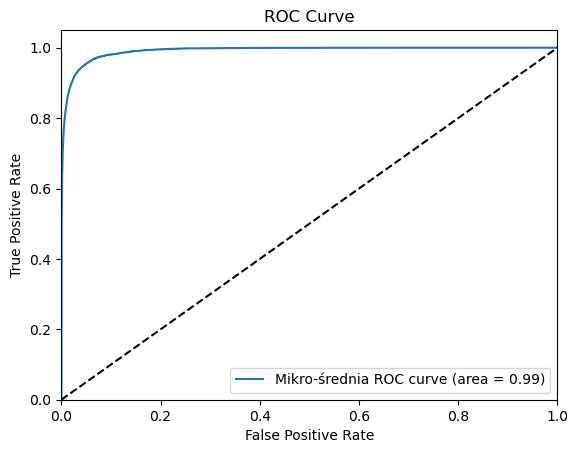

In [76]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Zakładając, że y_test jest w formie kategorialnej, nie binarnej
# Przekształcamy y_test do formatu binarnego
y_test_binarized = label_binarize(y_test, classes=range(len(class_names)))

# Obliczamy prawdopodobieństwa
y_prob = model_improved.predict(x_test)

# Obliczamy TPR i FPR dla wszystkich klas, a następnie mikro-średnią
fpr, tpr, thresholds = roc_curve(y_test_binarized.ravel(), y_prob.ravel())
roc_auc = auc(fpr, tpr)

# Rysowanie mikro-średniej ROC curve
plt.figure()
plt.plot(fpr, tpr, label='Mikro-średnia ROC curve (area = {0:0.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--')  # Linia odniesienia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

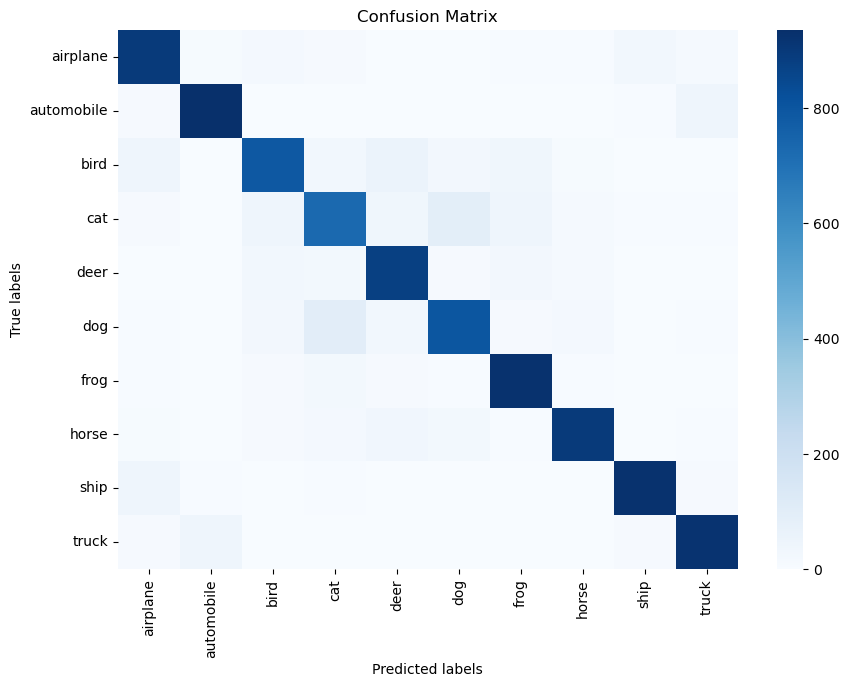

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Obliczanie macierzy błędów
cm = confusion_matrix(y_true, y_pred)

# Wizualizacja macierzy błędów
plt.figure(figsize=(10,7))
sns.heatmap(cm, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()